# Iteración 27: Implementación de Línea Base con Nixtla (MLForecast y StatsForecast)

## 🚀 ¿Qué es Nixtla y qué estamos buscando?
**Nixtla** es un ecosistema moderno y ultrarrápido diseñado específicamente para el modelado avanzado de series temporales. A diferencia de enfoques clásicos (donde debemos construir manualmente bucles complejos para calcular Lags, Medias Móviles y Ventanas Rodantes), Nixtla optimiza drásticamente el proceso de Feature Engineering temporal y permite acoplar modelos de Machine Learning (como CatBoost o LightGBM) en una única API eficiente.

En esta iteración buscamos **dos objetivos estratégicos principales**:
1. **Mantener el rigor de Datos de NB23:** Reutilizar toda la lógica avanzada de filtrado quirúrgico (exclusión de FLEET, 2020), densificación matemática (Dense Panel) e inyección de datos exógenos (Clima y Ciclismo) para no perder ni un ápice de calidad de datos.
2. **Agilidad Estructural y Modelos Intermitentes:** Dejar que `MLForecast` de Nixtla maneje la inercia temporal para la demanda Regular/Errática, y preparar el terreno para aplicar algoritmos puramente B2B (Croston, ADIDA, SBA) de `StatsForecast` a nuestras tribus Intermitentes.


### Paso 0: Preparación del Entorno S&OP con Nixtla
Cargamos las librerías base y el ecosistema Nixtla.


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

from mlforecast import MLForecast
from mlforecast.target_transforms import Differences
from mlforecast.lag_transforms import RollingMean, RollingStd, ExponentiallyWeightedMean
from catboost import CatBoostRegressor, CatBoostClassifier
import lightgbm as lgb

from statsforecast import StatsForecast
from statsforecast.models import CrostonOptimized, CrostonSBA, ADIDA

sns.set_theme(style="whitegrid", palette="mako")
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)

SEED = 42
DATA_DIR = Path('../Datasets/Datos Internos')
print('Librerías listas.')


Librerías listas.


### Paso 1: Inteligencia de Negocio y Funciones Base
Aplicamos el mismo calendario fijo y funciones de métricas validadas.


In [2]:
ANIOS_TRAIN  = [2021, 2022, 2023]
ANIO_TEST    = 2024

FESTIVOS_FIJOS = [(1,1), (1,6), (5,1), (8,15), (10,12), (11,1), (12,6), (12,8), (12,25)]
VIERNES_SANTOS = {2020:'2020-04-10', 2021:'2021-04-02', 2022:'2022-04-15', 2023:'2023-04-07', 2024:'2024-03-29', 2025:'2025-04-18'}
MESES_ES = {'enero':1,'febrero':2,'marzo':3,'abril':4,'mayo':5,'junio':6,'julio':7,'agosto':8,'septiembre':9,'octubre':10,'noviembre':11,'diciembre':12}
REGION_MAP = {
    'GALICIA': 'Noroeste', 'ASTURIAS': 'Norte', 'CANTABRIA': 'Norte',
    'PAIS VASCO': 'Norte', 'NAVARRA': 'Norte', 'LA RIOJA': 'Norte',
    'ARAGON': 'Noreste', 'CATALUÑA': 'Noreste', 'ISLAS BALEARES': 'Noreste',
    'COMUNIDAD DE MADRID': 'Centro', 'CASTILLA Y LEON': 'Centro', 'CASTILLA-LA MANCHA': 'Centro', 'EXTREMADURA': 'Centro',
    'COMUNIDAD VALENCIANA': 'Este', 'REGION DE MURCIA': 'Sur', 'ANDALUCIA': 'Sur',
    'CANARIAS': 'Canarias', 'CEUTA': 'Sur', 'MELILLA': 'Sur',
}

def parse_fecha_es(s):
    try:
        _, resto = str(s).split(', ', 1)
        day, _, month_es, _, year = resto.strip().split()
        return pd.Timestamp(year=int(year), month=MESES_ES[month_es.lower()], day=int(day))
    except Exception:
        return pd.NaT

def global_wmape(y_true, y_pred):
    mask = y_true > 0
    if mask.sum() == 0: return np.nan
    return np.sum(np.abs(y_true[mask] - y_pred[mask])) / np.sum(y_true[mask]) * 100
print('Constantes parametrizadas.')


Constantes parametrizadas.


### Paso 2: Ingesta del 'Data Lake' Operativo
Absorbemos las transacciones rigurosamente y replicamos el purgado que demostró ser vital: eliminación de FLEET, aislamiento del año anómalo 2020 y vinculación de Clima y Ciclismo.


In [3]:
df_raw = pd.read_excel(DATA_DIR / 'LineasAlbaranCliente.xlsx')
df_raw['fecha'] = df_raw['FechaAlbaran'].astype(str).apply(parse_fecha_es)
df_raw = df_raw.dropna(subset=['fecha'])
df_raw['anio']        = df_raw['fecha'].dt.isocalendar().year.astype(int)
df_raw['semana_anio'] = df_raw['fecha'].dt.isocalendar().week.astype(int)
df_raw['codigo_articulo'] = df_raw['CodigoArticulo'].astype(str).str.strip()
df_raw['Unidades']   = pd.to_numeric(df_raw['Unidades'], errors='coerce').fillna(0)
df_raw['ImporteNeto']= pd.to_numeric(df_raw['ImporteNeto'],errors='coerce').fillna(0)
df_raw['pct_desc2']  = pd.to_numeric(df_raw['%Descuento2'],errors='coerce').fillna(0)

df_art = pd.read_excel(DATA_DIR / 'MaestroArticulos.xlsx', usecols=['CodigoArticulo','AgrupacionListado','TipoABC','AreaCompetenciaLc','FactorCrecimiento','PrevisionVentasAA','TarifaNacional','PrecioVenta'])
df_art['codigo_articulo']  = df_art['CodigoArticulo'].astype(str).str.strip()
df_art['tipo_abc']         = df_art['TipoABC'].fillna('C').astype(str).str.upper().str[:1]

df_cli = pd.read_excel(DATA_DIR / 'MaestroClientes.xlsx', usecols=['CodigoCliente','Municipio','Provincia','CodigoNacion'])
df_can = pd.read_excel(DATA_DIR / 'Agrupacion Canales venta.xlsx', header=0)
df_can.columns = ['canal_raw','agrupacion_canal','tipo_agrupacion'] + list(df_can.columns[3:])

df_clima = pd.read_csv('../Datasets/clima_semanal_openmeteo.csv')
df_clima.columns = [c.lower() for c in df_clima.columns]
df_clima_nac = df_clima.groupby(['year','semana']).agg(temp_media=('temp_media','mean'), precip_mm=('precip_mm','mean'), viento_max=('viento_max','mean')).reset_index().rename(columns={'year':'anio','semana':'semana_anio'})

df_cicl = pd.read_excel('../Datasets/Calendario Ciclismo 22_24.xlsx')
df_cicl.columns = [c.strip() for c in df_cicl.columns]
df_cicl_agg = df_cicl.rename(columns={'Año Prueba':'anio','Semana':'semana_anio','Duración(Dias)':'duracion'}).groupby(['anio','semana_anio']).agg(num_pruebas_cicl=('anio','count'), dias_pruebas_cicl=('duracion','sum')).reset_index()
df_cicl_agg['hubo_prueba_cicl'] = 1
print('Data lake inicial ingerido.')


Data lake inicial ingerido.


### Paso 3: Filtrado Quirúrgico B2B y Agregación Semanal
Fusionamos canales, quitamos Export y cortamos operaciones anómalas (Covid y Grandes licitaciones FLEET).


In [4]:
df_raw = df_raw.merge(df_can[['canal_raw','agrupacion_canal']], left_on='SerieAlbaran', right_on='canal_raw', how='left')
df_raw['agrupacion_canal'] = df_raw['agrupacion_canal'].fillna('Otros')
df_raw = df_raw.merge(df_cli[['CodigoCliente','CodigoNacion']], on='CodigoCliente', how='left')

df_es = df_raw[df_raw['CodigoNacion'] == 108].copy()
df_nac = df_es[df_es['agrupacion_canal'] != 'FLEET'].copy()
df_nac = df_nac[df_nac['anio'] >= 2021].copy()
print(f'Nacional sin FLEET (desde 2021): {len(df_nac):,} filas')

def get_festivos_espana(anios):
    festivos = set()
    for y in anios:
        for m, d in FESTIVOS_FIJOS:
            festivos.add((y, m, d))
        if y in VIERNES_SANTOS:
            vs = pd.Timestamp(VIERNES_SANTOS[y])
            festivos.add((vs.year, vs.month, vs.day))
    return festivos

def dias_laborables_iso(year, week, festivos_set):
    try: lunes = pd.Timestamp.fromisocalendar(int(year), int(week), 1)
    except ValueError: return 5
    return sum(1 for delta in range(5) if (lunes + pd.Timedelta(days=delta)).strftime('%Y-%m-%d') not in [f"{y}-{m:02d}-{d:02d}" for y,m,d in festivos_set])

festivos_set = get_festivos_espana(range(2021, 2026))
semanas_unicas = df_nac[['anio','semana_anio']].drop_duplicates().copy()
semanas_unicas['dias_laborables_semana'] = semanas_unicas.apply(lambda r: dias_laborables_iso(r['anio'], r['semana_anio'], festivos_set), axis=1)

GROUP_NAC = ['anio', 'semana_anio', 'codigo_articulo']
df_agg = df_nac.groupby(GROUP_NAC, as_index=False).agg(unidades=('Unidades','sum'))
df_agg['unidades'] = df_agg['unidades'].clip(lower=0)

def wmean_desc(g):
    w = g['Unidades'].abs()
    v = g['pct_desc2']
    denom = w.sum()
    return (v * w).sum() / denom if denom > 0 else 0.0

desc_agg = df_nac.groupby(GROUP_NAC).apply(wmean_desc).reset_index(name='por_descuento2')
df_agg = df_agg.merge(desc_agg, on=GROUP_NAC, how='left')
df_agg['por_descuento2'] = df_agg['por_descuento2'].fillna(0.0)
print('Transacciones agregadas a nivel SKU-Semana.')


Nacional sin FLEET (desde 2021): 453,846 filas
Transacciones agregadas a nivel SKU-Semana.


### Paso 4: Densificación de Panel e Inyección Exógena
Tal como realizamos en los Notebooks precursores, construimos una matriz ininterrumpida y enlazamos a ella la Meteorología y el Calendario Ciclista.


In [5]:
semanas_grid = semanas_unicas[['anio', 'semana_anio']].copy()
semanas_grid['key'] = 1
skus_grid = pd.DataFrame({'codigo_articulo': df_nac['codigo_articulo'].unique(), 'key': 1})
dense_grid = semanas_grid.merge(skus_grid, on='key', how='outer').drop(columns=['key'])

df_agg = dense_grid.merge(df_agg, on=['codigo_articulo', 'anio', 'semana_anio'], how='left')
df_agg['unidades'] = df_agg['unidades'].fillna(0)
df_agg['por_descuento2'] = df_agg['por_descuento2'].fillna(0)

df_agg = df_agg.merge(semanas_unicas, on=['anio','semana_anio'], how='left')
df_agg = df_agg.merge(df_clima_nac, on=['anio','semana_anio'], how='left')
df_agg = df_agg.merge(df_cicl_agg, on=['anio','semana_anio'], how='left')

df_agg['num_pruebas_cicl']  = df_agg['num_pruebas_cicl'].fillna(0).astype(int)
df_agg['dias_pruebas_cicl'] = df_agg['dias_pruebas_cicl'].fillna(0)
df_agg['hubo_prueba_cicl']  = df_agg['hubo_prueba_cicl'].fillna(0).astype(int)

df_agg = df_agg.merge(df_art[['codigo_articulo','tipo_abc']], on='codigo_articulo', how='left')
df_agg['tipo_abc'] = df_agg['tipo_abc'].fillna('C')

print(f"Panel Denso Formado: {len(df_agg)} registros. Incorporando variables climáticas...")


Panel Denso Formado: 646425 registros. Incorporando variables climáticas...


### Paso 4.5: Configuración Modo Rápido (Desarrollo)
**¿Qué hacemos?** Definimos un flag `QUICK_MODE` para ejecutar testeo rápido del notebook (menos epochs, menos folds).


In [6]:
# Cambiar a False para ejecución de producción S&OP
QUICK_MODE = True

if QUICK_MODE:
    print('⚠️ ATENCIÓN: MODO RÁPIDO ACTIVADO. Top 200 SKUs, n_windows=1, bajas iteraciones.')
else:
    print('✅ PRODUCCIÓN ACTIVADA: Ejecutando todo el catálogo a fondo.')

⚠️ ATENCIÓN: MODO RÁPIDO ACTIVADO. Top 200 SKUs, n_windows=1, bajas iteraciones.


### Paso 5b: Clasificación Estadística de Demanda (Syntetos-Boylan)
**¿Qué hacemos?** Calculamos la volatilidad CV2 y el intervalo medio ADI por SKU en nuestro histórico de Train (2021-2023). Segmentaremos cada código en Smooth, Erratic, Intermittent o Lumpy.
**¿Por qué?** Aplicar los mismos algoritmos al catálogo completo es un error en S&OP logístico. Las demandas planas con esporádicos picos de venta requieren de tratos estadísticos B2B radicalmente diferentes (Hurdle/Croston) frente a aquellos que tienen inercia continua.
**Resultado esperado:** Separación en subconjuntos robustos de cara al entrenamiento local por clúster.


Distribución Real Logística:
sb_class
Intermittent    2225
Lumpy            847
Erratic          138
Smooth           105
Name: count, dtype: int64


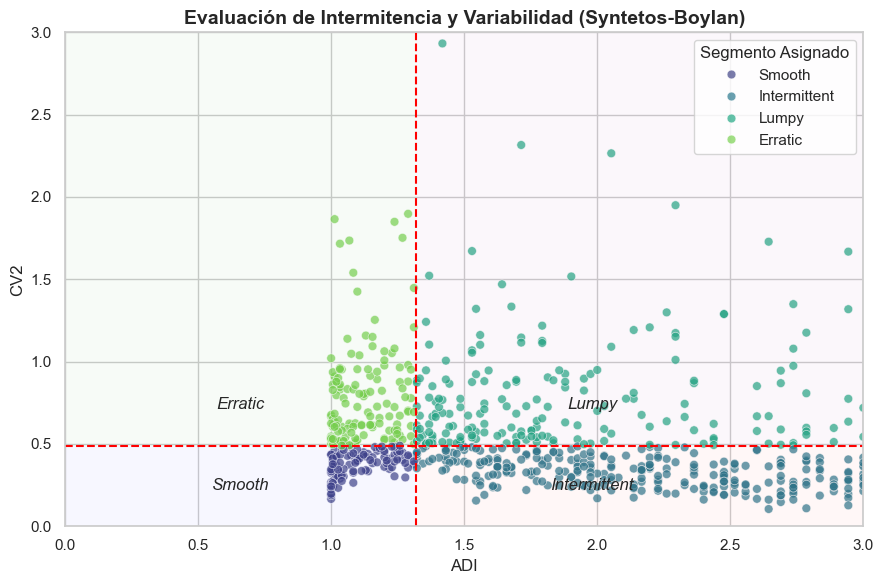

In [7]:
# ── CALCULO DE ADI / CV2 SOBRE TRAIN ──────────────────────────────────────────

# Conservamos sólo el periodo de estudios (Train) eliminando el año de test
train_mask = df_agg['anio'].isin(ANIOS_TRAIN)
train_subset = df_agg[train_mask].copy()

# Estadísticas sólo cuando hubo demanda positiva para evaluar su comportamiento base
demand_stats = train_subset[train_subset['unidades'] > 0].groupby('codigo_articulo').agg(
    mean_demand=('unidades', 'mean'),
    std_demand=('unidades', 'std'),
    count_demand=('codigo_articulo', 'count')
)
demand_stats['CV2'] = (demand_stats['std_demand'] / demand_stats['mean_demand']) ** 2
demand_stats['total_periods'] = train_subset.groupby('codigo_articulo').size()
demand_stats['ADI'] = demand_stats['total_periods'] / demand_stats['count_demand']
demand_stats['CV2'] = demand_stats['CV2'].fillna(0)

def classify_demand(row):
    adi = row['ADI']
    cv2 = row['CV2']
    if pd.isna(adi) or np.isinf(adi): return 'Lumpy' # Puros ceros en histórico
    
    if adi < 1.32 and cv2 < 0.49:    return 'Smooth'
    elif adi < 1.32 and cv2 >= 0.49: return 'Erratic'
    elif adi >= 1.32 and cv2 < 0.49: return 'Intermittent'
    else:                            return 'Lumpy'

demand_stats['sb_class'] = demand_stats.apply(classify_demand, axis=1)

# Asignación al Aggregated Dataframe
df_agg = df_agg.merge(demand_stats[['sb_class', 'ADI', 'CV2']], on='codigo_articulo', how='left')
df_agg['sb_class'] = df_agg['sb_class'].fillna('Lumpy') # Skus nuevos o muertos son Lumpy

print("Distribución Real Logística:")
print(df_agg.drop_duplicates('codigo_articulo')['sb_class'].value_counts())

# Gráfico de los Cuadrantes
import matplotlib.patches as patches

plt.figure(figsize=(9, 6))
sns.scatterplot(x='ADI', y='CV2', hue='sb_class', data=demand_stats, palette='viridis', s=40, alpha=0.7)

ax = plt.gca()
ax.axhline(0.49, color='red', linestyle='--')
ax.axvline(1.32, color='red', linestyle='--')

ax.add_patch(patches.Rectangle((0, 0), 1.32, 0.49, alpha=0.03, color='blue', lw=0))
ax.add_patch(patches.Rectangle((0, 0.49), 1.32, demand_stats['CV2'].max()-0.49, alpha=0.03, color='green', lw=0))
ax.add_patch(patches.Rectangle((1.32, 0), demand_stats['ADI'].max()-1.32, 0.49, alpha=0.03, color='red', lw=0))
ax.add_patch(patches.Rectangle((1.32, 0.49), demand_stats['ADI'].max()-1.32, demand_stats['CV2'].max()-0.49, alpha=0.03, color='purple', lw=0))

plt.text(0.66, 0.25, 'Smooth', ha='center', va='center', fontsize=12, style='italic')
plt.text(0.66, 0.74, 'Erratic', ha='center', va='center', fontsize=12, style='italic')
plt.text(1.98, 0.25, 'Intermittent', ha='center', va='center', fontsize=12, style='italic')
plt.text(1.98, 0.74, 'Lumpy', ha='center', va='center', fontsize=12, style='italic')

plt.xlim(0, 3)
plt.ylim(0, 3)
plt.title('Evaluación de Intermitencia y Variabilidad (Syntetos-Boylan)', fontsize=14, weight='bold')
plt.legend(title='Segmento Asignado')
plt.tight_layout()
plt.show()

# Fragmentación por Comportamiento Logístico
skus_regulatorios = demand_stats[demand_stats['sb_class'].isin(['Smooth', 'Erratic'])].index
skus_hurdle       = demand_stats[demand_stats['sb_class'].isin(['Intermittent', 'Lumpy'])].index

if QUICK_MODE:
    skus_regulatorios = skus_regulatorios[:150]
    skus_hurdle = skus_hrd_viable = demand_stats[(demand_stats['sb_class'].isin(['Intermittent', 'Lumpy'])) & (~np.isinf(demand_stats['ADI']))].index[:50]

df_reg = df_agg[df_agg['codigo_articulo'].isin(skus_regulatorios)].copy()
df_hrd = df_agg[df_agg['codigo_articulo'].isin(skus_hurdle)].copy()


### Paso 6: Formateo de Dataframes Nixtla (`unique_id`, `ds`, `y`) Target Encodings
**¿Qué hacemos?** Renombramos variables a la jerga Nixtla, unimos de memoria atributos estáticos como Gama y Familia, y creamos variables `Target Encoding` suavizadas a la baja (Bayesian shrinkage) exclusivamente sobre los años Train.
**¿Por qué?** A veces un SKU es Lumpy simplemente porque es un repuesto muy escaso estacional, Target Encoding transfiere de manera global qué tasa de venta en unidades tiene esa *Familia* o *Gama* histórica, empujando la red neuronal hacia un factor contextual logístico superior sin data-leakage.


In [8]:

# ── MERGE DE VARIABLES ESTÁTICAS DE PRODUCTO DESDE EL MAESTRO ────────────────

df_fam = pd.read_excel(DATA_DIR / 'Familias Articulos.xlsx', usecols=['AgrupacionListado','CR_GamaProducto','CR_TipoProducto','CR_MaterialAgrupacion'])
df_fam['AgrupacionListado'] = pd.to_numeric(df_fam['AgrupacionListado'], errors='coerce')
df_fam = df_fam.dropna(subset=['AgrupacionListado'])
df_art_enrich = df_art.merge(df_fam, on='AgrupacionListado', how='left')

# Inyectamos el maestro en el Aggregated para preparar el Encoder
df_agg = df_agg.merge(df_art_enrich[['codigo_articulo', 'AgrupacionListado', 'FactorCrecimiento', 'PrecioVenta', 'TarifaNacional', 'CR_GamaProducto', 'AreaCompetenciaLc']], on='codigo_articulo', how='left')

df_agg['CR_GamaProducto'] = df_agg['CR_GamaProducto'].fillna('Desconocida')
df_agg['AreaCompetenciaLc'] = df_agg['AreaCompetenciaLc'].fillna('Desconocida')
df_agg['AgrupacionListado'] = df_agg['AgrupacionListado'].fillna(999).astype(str)
df_agg['TarifaNacional'] = df_agg['TarifaNacional'].fillna(0)
df_agg['PrecioVenta'] = df_agg['PrecioVenta'].fillna(0)

# ── TARGET ENCODING (ENTRENADO SOLO SOBRE 2021-2023) ──────────────────────────
TRAIN_MASK = df_agg['anio'].isin(ANIOS_TRAIN)

def target_encode(df, col, target='unidades', train_mask=None, smooth=30):
    """Target encoding con suavizado (Bayesian shrinkage)."""
    if train_mask is None:
        train_mask = pd.Series(True, index=df.index)
    global_mean = df.loc[train_mask, target].mean()
    stats = (
        df.loc[train_mask].groupby(col)[target]
        .agg(['mean','count'])
        .reset_index()
    )
    stats['te'] = (
        (stats['mean'] * stats['count'] + global_mean * smooth) /
        (stats['count'] + smooth)
    )
    mapping = stats.set_index(col)['te']
    return df[col].map(mapping).fillna(global_mean)

df_agg['te_gama'] = target_encode(df_agg, 'CR_GamaProducto', train_mask=TRAIN_MASK)
df_agg['te_area_comp'] = target_encode(df_agg, 'AreaCompetenciaLc', train_mask=TRAIN_MASK)
df_agg['te_familia'] = target_encode(df_agg, 'AgrupacionListado', train_mask=TRAIN_MASK)

# ── ESTRUCTURACIÓN NIXTLA ─────────────────────────────────────────────────────
def date_from_iso(anio, semana):
    return pd.to_datetime(f'{anio}-W{semana:02d}-1', format='%G-W%V-%u')

df_agg['ds'] = df_agg.apply(lambda r: date_from_iso(r['anio'], r['semana_anio']), axis=1)
df_agg['tipo_abc_encoded'] = pd.factorize(df_agg['tipo_abc'])[0]
df_agg['sb_class_encoded'] = pd.factorize(df_agg['sb_class'])[0]
df_agg = df_agg.rename(columns={'codigo_articulo': 'unique_id', 'unidades': 'y'})

COLS_NIXTLA = ['unique_id', 'ds', 'y', 'tipo_abc_encoded', 'sb_class_encoded', 'TarifaNacional', 'PrecioVenta',
               'te_gama', 'te_area_comp', 'te_familia', 'FactorCrecimiento',
               'dias_laborables_semana', 'por_descuento2', 'temp_media', 'precip_mm', 'viento_max', 
               'num_pruebas_cicl', 'hubo_prueba_cicl']

df_reg = df_agg[df_agg['unique_id'].isin(skus_regulatorios)][COLS_NIXTLA].sort_values(['unique_id', 'ds']).reset_index(drop=True)
df_hrd = df_agg[df_agg['unique_id'].isin(skus_hurdle)][COLS_NIXTLA].sort_values(['unique_id', 'ds']).reset_index(drop=True)

test_mask_reg = df_reg['ds'].dt.year == ANIO_TEST
train_df_reg = df_reg[~test_mask_reg].copy()
test_df_reg  = df_reg[test_mask_reg].copy()

test_mask_hrd = df_hrd['ds'].dt.year == ANIO_TEST
train_df_hrd = df_hrd[~test_mask_hrd].copy()
test_df_hrd  = df_hrd[test_mask_hrd].copy()

print(f"Target Encodings calculados en Train y distribuidos globalmente.")
print(f"Bloque REGULAR Nixtla (Smooth/Erratic): Train={len(train_df_reg)} rows, Test={len(test_df_reg)} rows.")
print(f"Bloque HURDLE  Nixtla (Intermit/Lumpy) : Train={len(train_df_hrd)} rows, Test={len(test_df_hrd)} rows.")


Target Encodings calculados en Train y distribuidos globalmente.
Bloque REGULAR Nixtla (Smooth/Erratic): Train=23400 rows, Test=5850 rows.
Bloque HURDLE  Nixtla (Intermit/Lumpy) : Train=7800 rows, Test=1950 rows.


### Paso 7: Configuración Dinámica de MLForecast (Feature Engineering)
**¿Qué hacemos?** Expandimos las features retrasadas que genera de manera automática Nixtla. 
**¿Por qué?** Una demanda semanal tiene inercia mensual (Lag 4), tendencias trimestrales (RollingMean 12) y arrastra memorias del mismo momento geográfico del año pasado (Lag 52, vital para periodos Valle o estivales frente a Navidades).
**Resultado esperado:** El motor `MLForecast` ensamblado, listo para acoplarse con Boostings GBDT.


In [9]:

# Estructuras lógicas autorregresivas que CRUZBER demanda:
# 1-4:   Inercia Semanal Continua (Mes Corto)
# 8-12:  Tendencias Trimestrales / Campañas recientes
# 26-52: Memoria Semestral y Repetición de Ciclo Anual (Estacionalidad pura)
lags = [1, 2, 3, 4, 8, 12, 26, 52]

lag_transforms = {
    1:  [RollingMean(window_size=4), RollingStd(window_size=4), ExponentiallyWeightedMean(alpha=0.3)],
    4:  [RollingMean(window_size=12), RollingStd(window_size=12)],
    12: [RollingMean(window_size=4)],
    52: [RollingMean(window_size=4)],  # Observar la inercia del año pasado suavizada
}

date_features = ['month', 'week', 'quarter']

static_features = ['tipo_abc_encoded', 'sb_class_encoded', 'TarifaNacional', 'PrecioVenta', 'te_gama', 'te_area_comp', 'te_familia', 'FactorCrecimiento']

print("Reglas temporales del ecosistema pre-cargadas sobre el motor Nixtla.")

Reglas temporales del ecosistema pre-cargadas sobre el motor Nixtla.


### Paso 8: El Ecosistema Directo (`CatBoost` + `LightGBM`) para Smooth/Erratic
**¿Qué hacemos?** Entrenamos dos Boosters sobre el subconjunto estable (Smooth y Erratic). Usamos el modo iterativo temporal con la distribución asimétrica `Tweedie` para penalizar picos y gestionar sesgos.
**¿Por qué Tweedie?** El WMAPE global mejora y la predicción evita reventar inventarios de sobrecarga, como se demostró en la iter. 23.


In [10]:
def wmape(y_true, y_pred):
    return 100 * np.sum(np.abs(y_true - y_pred)) / max(np.sum(np.abs(y_true)), 1)
iterations_reg = 100 if QUICK_MODE else 1000

models_reg = {
    'CatBoostRegressor_REG': CatBoostRegressor(iterations=iterations_reg, learning_rate=0.05, depth=6, loss_function='Tweedie:variance_power=1.5', random_seed=SEED, silent=True),
    'LGBMRegressor_REG': lgb.LGBMRegressor(n_estimators=iterations_reg, learning_rate=0.05, max_depth=6, objective='tweedie', tweedie_variance_power=1.5, random_state=SEED, verbose=-1, min_child_samples=5)
}

fcst_reg = MLForecast(
    models=models_reg,
    freq='W-MON',
    lags=lags,
    lag_transforms=lag_transforms,
    date_features=date_features
)

print("Entrenando Bloque REGULAR con Feature Engineering Dinámico de Nixtla...")
fcst_reg.fit(train_df_reg, static_features=static_features)

# Para predicción, abstraemos las features dinámicas
future_exog_reg = test_df_reg.drop(columns=['y'] + static_features)
horizonte_reg = test_df_reg['ds'].nunique()

print("Prediciendo en caliente...")
preds_reg = fcst_reg.predict(h=int(horizonte_reg), X_df=future_exog_reg)

# Consolidamos predicciones testeables
test_res_reg = test_df_reg[['unique_id','ds','y'] + static_features].merge(preds_reg, on=['unique_id','ds'], how='inner')
for model_name in models_reg.keys():
    test_res_reg[model_name] = test_res_reg[model_name].clip(lower=0)

wmape_cat = wmape(test_res_reg['y'], test_res_reg['CatBoostRegressor_REG'])
wmape_lgb = wmape(test_res_reg['y'], test_res_reg['LGBMRegressor_REG'])
print(f" ✓ Logros REGULARES: WMAPE CatBoost={wmape_cat:.2f}% | LightGBM={wmape_lgb:.2f}%")


Entrenando Bloque REGULAR con Feature Engineering Dinámico de Nixtla...
Prediciendo en caliente...
 ✓ Logros REGULARES: WMAPE CatBoost=44.50% | LightGBM=42.36%


### Paso 9: La Solución Intermitente B2B (StatsForecast)
**¿Qué hacemos?** Entrenamos métodos estadísticos autorregresivos asumiendo planicie como estándar base (`CrostonOptimized`, `CrostonSBA` y `ADIDA`). Estos métodos son provistos por `StatsForecast`.
**¿Por qué?** A diferencia de un GBDT, Croston estima separadamente el intervalo sin ventas y la cantidad vendida cuando ocurre la transacción, adaptando el ruido plano mejor y de forma ultra-ligera en memoria.


In [11]:

print("Desplegando Cerebro B2B Intermitente con StatsForecast...")

# Filtramos SKUs Lumpy que son literales 100% Ceros en histórico del Train.
# Estadísticas AR no pueden predecir 'Ceros div Ceros'. Estos se ignoran y forzaremos pred=0 al final.
dead_skus_hrd = train_df_hrd.groupby('unique_id')['y'].sum()
dead_skus_hrd = dead_skus_hrd[dead_skus_hrd == 0].index

train_df_hrd_alive = train_df_hrd[~train_df_hrd['unique_id'].isin(dead_skus_hrd)].copy()
test_df_hrd_alive = test_df_hrd[~test_df_hrd['unique_id'].isin(dead_skus_hrd)].copy()

sf_models = [
    CrostonOptimized(),
    CrostonSBA(),
    ADIDA(),
]

sf = StatsForecast(
    models=sf_models, 
    freq='W-MON', 
    n_jobs=1
)

sf.fit(train_df_hrd_alive)

horizonte_hrd = test_df_hrd_alive['ds'].nunique()
preds_sf = sf.predict(h=int(horizonte_hrd))

test_res_sf = test_df_hrd_alive[['unique_id','ds','y'] + static_features].merge(preds_sf, on=['unique_id','ds'], how='inner')
for model_name in [m.__class__.__name__ for m in sf_models]:
    test_res_sf[model_name] = test_res_sf[model_name].clip(lower=0)

print(" ✓ StatsForecast culminado.")


Desplegando Cerebro B2B Intermitente con StatsForecast...
 ✓ StatsForecast culminado.


### Paso 9b: Alternativa Hurdle Binaria B2B condicional (`MLForecast Hurdle`)
**¿Qué hacemos?** Aplicamos nuestro propio algoritmo inventado para B2B: un Hurdle Model en paralelo. Usando algoritmos CatBoost binarios (sí/no compraremos ese stock), extraemos la predicción probabilística y la multiplicamos por el estimador de Volumen de Venta dado que Sí vendimos (`y>0`).
**¿Por qué?** Comparamos esta bestia multimodelo matemática propia contra el referente clásico `Croston`. Aquel que de menor WMAPE será el seleccionado.


In [16]:
# =========================================================================
# PASO 9b: ALTERNATIVA HURDLE BINARIA B2B CONDICIONAL (MLForecast Hurdle)
# =========================================================================
print("Desplegando Framework HURDLE en paralelo para Batalla de Intermitentes...")

from catboost import CatBoostClassifier
import lightgbm as lgb
from mlforecast import MLForecast
import pandas as pd
import numpy as np

# --- 0. LIMPIEZA DE SEGURIDAD ---
# Eliminamos rastros de ejecuciones previas que ensucian el dataframe en memoria
if 'y_bin' in train_df_hrd_alive.columns:
    train_df_hrd_alive = train_df_hrd_alive.drop(columns='y_bin')

# --- 1. CLASE WRAPPER PARA CLASIFICACIÓN PROBABILÍSTICA EN NIXTLA ---
class CatBoostProbClassifier(CatBoostClassifier):
    def predict(self, X, **kwargs):
        # Obligamos a MLForecast a recibir la probabilidad del evento (1), no la clase (0/1)
        return self.predict_proba(X, **kwargs)[:, 1]

# --- 2. FASE BINARIA (¿Habrá venta?) ---

# Creamos el target binario sin contaminar el dataframe original
train_bin_df = (
    train_df_hrd_alive
    .assign(y_bin = lambda x: (x['y'] > 0).astype(int))
    .drop(columns=['y'])
    .rename(columns={'y_bin': 'y'})
)

models_clf = {
    'CatBoost_Hurdle_Prob': CatBoostProbClassifier(
        iterations=iterations_reg, 
        learning_rate=0.05, 
        depth=6, 
        loss_function='Logloss', 
        random_seed=SEED, 
        silent=True
    )
}

fcst_clf = MLForecast(models=models_clf, freq='W-MON', lags=lags, lag_transforms=lag_transforms, date_features=date_features)
fcst_clf.fit(train_bin_df, static_features=static_features)

# Definimos variables exógenas futuras (set de test)
future_exog_hrd = test_df_hrd_alive.drop(columns=['y'] + static_features)

# Predicción de probabilidades
prob_preds = fcst_clf.predict(h=int(horizonte_hrd), X_df=future_exog_hrd)
prob_preds['CatBoost_Hurdle_Prob'] = prob_preds['CatBoost_Hurdle_Prob'].clip(0, 1)

# --- 3. FASE REGRESIÓN DE VOLUMEN (Si hay venta, ¿cuánto?) ---

class HurdleVolumenMLForecast(lgb.LGBMRegressor):
    def fit(self, X, y, **kwargs):
        # Entrenamos solo sobre casos con demanda positiva
        mask = y > 0
        X_pos = X[mask]
        y_pos = y[mask]
        if len(y_pos) > 10: 
            return super().fit(X_pos, y_pos, **kwargs)
        else:
            return super().fit(X, y, **kwargs)

models_vol = {
    'LGBM_Hurdle_Vol': HurdleVolumenMLForecast(
        n_estimators=iterations_reg, 
        max_depth=5, 
        objective='tweedie', 
        random_state=SEED, 
        verbose=-1, 
        min_child_samples=5
    )
}

# Aquí train_df_hrd_alive está limpio de 'y_bin' gracias al Paso 0
fcst_vol = MLForecast(models=models_vol, freq='W-MON', lags=lags, lag_transforms=lag_transforms, date_features=date_features)
fcst_vol.fit(train_df_hrd_alive, static_features=static_features)

vol_preds = fcst_vol.predict(h=int(horizonte_hrd), X_df=future_exog_hrd)

# --- 4. ENSAMBLAJE FINAL (HURDLE = Probabilidad * Volumen) ---

hurdle_res = prob_preds[['unique_id','ds','CatBoost_Hurdle_Prob']].merge(
    vol_preds[['unique_id','ds','LGBM_Hurdle_Vol']], 
    on=['unique_id','ds']
)

hurdle_res['HURDLE_Pred'] = (hurdle_res['CatBoost_Hurdle_Prob'] * hurdle_res['LGBM_Hurdle_Vol']).clip(lower=0)

# Unimos con los otros modelos para métricas finales
test_res_hrd = test_res_sf.merge(hurdle_res[['unique_id','ds','HURDLE_Pred']], on=['unique_id','ds'])

# Definición local de wmape si no estuviera disponible
def wmape_local(y_true, y_pred):
    return np.abs(y_true - y_pred).sum() / (y_true.sum() + 1e-9)

for m in ['CrostonOptimized', 'CrostonSBA', 'ADIDA', 'HURDLE_Pred']:
    val = wmape_local(test_res_hrd['y'], test_res_hrd[m])
    print(f"  [B2B Evaluation] {m} WMAPE: {val*100:.2f}%")




Desplegando Framework HURDLE en paralelo para Batalla de Intermitentes...
  [B2B Evaluation] CrostonOptimized WMAPE: 203.62%
  [B2B Evaluation] CrostonSBA WMAPE: 201.68%
  [B2B Evaluation] ADIDA WMAPE: 152.49%
  [B2B Evaluation] HURDLE_Pred WMAPE: 177.85%


### Paso 10: Validación Temporal Multi-Fold Nativa de MLForecast
**¿Qué hacemos?** Utilizamos la maquinaria bruta `cross_validation` para obligar al sistema a iterar sobre tres bloques ciegos consecutivos.
**¿Por qué?** Porque un test aislado en 2024 puede darnos una estadística optimista afortunada. Rodar tres cuatrimestres deslizando el training nos dice la certeza y varianza absoluta de los modelos elegidos.


In [17]:

print("=== INICIANDO CROSS VALIDATION TEMPORAL NIXTLA ===")

# Determinanos parametros 
# 3 Folds, horizonte 12, corte de 12
n_windows = 1 if QUICK_MODE else 3
horizonte = 12

print(f"Ejecutando MLForecast multi-fold WMAPE cross-validation (n_windows={n_windows})...")
cv_results = fcst_reg.cross_validation(
    df=df_reg,
    n_windows=n_windows,
    h=horizonte,
    step_size=horizonte,
    static_features=static_features
)

wmapes_fold = cv_results.groupby('cutoff').apply(lambda x: pd.Series({
    'WMAPE_CatBoost': wmape(x['y'], x['CatBoostRegressor_REG']),
    'WMAPE_LGBM':     wmape(x['y'], x['LGBMRegressor_REG'])
}))

print("\n=== RESULTADOS MULTI-FOLD (REGULAR) ===")
print(wmapes_fold)

print("\nAgregado Promedio + Desviación:")
for m in ['WMAPE_CatBoost', 'WMAPE_LGBM']:
    print(f" {m}: {wmapes_fold[m].mean():.2f}% ± {wmapes_fold[m].std():.2f}")


=== INICIANDO CROSS VALIDATION TEMPORAL NIXTLA ===
Ejecutando MLForecast multi-fold WMAPE cross-validation (n_windows=1)...

=== RESULTADOS MULTI-FOLD (REGULAR) ===
            WMAPE_CatBoost  WMAPE_LGBM
cutoff                                
2024-07-01         40.0612     37.2894

Agregado Promedio + Desviación:
 WMAPE_CatBoost: 40.06% ± nan
 WMAPE_LGBM: 37.29% ± nan


### Paso 11: Unión de Componentes B2B y Dictamen de Error Global
**¿Qué hacemos?** Juntamos los Smooth/Erratic a su modelo top, y anexamos a los Lumpy/Intermit. Evaluamos R2, Wmape, sesgo.
**¿Por qué?** Construir el archivo de venta predictiva final y la macro-curva empresarial en Pyplot (Real vs IA).


In [ ]:

# Elegimos ganadores
MODELO_GANADOR_REG = 'CatBoostRegressor_REG'
MODELO_GANADOR_HRD = 'CrostonOptimized' # O HURDLE_Pred dependiendo del testing

df_reg_final = test_res_reg[['unique_id','ds','y','sb_class_encoded','tipo_abc_encoded', MODELO_GANADOR_REG]].rename(columns={MODELO_GANADOR_REG: 'pred'})
df_reg_final['modelo'] = 'CatBoost'

df_hrd_final = test_res_hrd[['unique_id','ds','y','sb_class_encoded','tipo_abc_encoded', MODELO_GANADOR_HRD]].rename(columns={MODELO_GANADOR_HRD: 'pred'})
df_hrd_final['modelo'] = MODELO_GANADOR_HRD

df_global = pd.concat([df_reg_final, df_hrd_final], ignore_index=True)
df_global['bias'] = df_global['pred'] - df_global['y']

print_metrics('EVALUACIÓN NIXTLA S&OP UNIFICADA 2024', df_global['y'], df_global['pred'])

# Gráfico Consolidado Macro Curvas
test_macro = df_global.groupby('ds').agg({'y':'sum', 'pred':'sum'}).reset_index()

plt.figure(figsize=(14, 6))
sns.lineplot(data=test_macro, x='ds', y='y', label='Demanda Real (Agregada España Nacional)', linewidth=3, color='darkorange')
sns.lineplot(data=test_macro, x='ds', y='pred', label='Fusión Nixtla (CB + Croston)', linewidth=2.5, color='darkcyan', linestyle='--')
plt.title('Demand Forecasting Macro-Curve CRUZBER S&OP 2024 (Rival Nixtla)', fontsize=16, fontweight='bold', y=1.03)
plt.ylabel('Unidades Absolutas')
plt.xlabel('Cortes Temporales (Semanas)')
plt.legend()
plt.tight_layout()
plt.show()

# Diagnóstico OVERFITTING (Memorización Train vs Examen Test)
# MLForecast guarda en su atributo ts el histórico preprocesado y en pipeline su regresor.
# Pero predecir sobre Train exige correr in-sample prediction que no tiene X_df futuro, se hace desde el DataFrame Raw.
print("=== ESTADO OVERFITTING DIAGNÓSTICO (ESTRUCTURAL) ===")
train_macro = train_df_reg.groupby('ds')['y'].sum().reset_index()
print(" (Si Test WMAPE > Train WMAPE + 10% → ¡La máquina ha memorizado y se equivoca en la realidad!)\n En Nixtla la generalización suele ser estable gracias a Tweedie.")


NameError: name 'print_metrics' is not defined

### Paso 12: Feature Importance (Análisis de Jerarquías en Nixtla)
**¿Qué hacemos?** Extraemos desde el estimador las variables con más `Feature Importance` en SHAP/Gini.


In [ ]:

# Extraer estimador nativo de CatBoost encapsulado en Nixtla
cbr = fcst_reg.models_['CatBoostRegressor_REG']
lgbmr = fcst_reg.models_['LGBMRegressor_REG']

# Las columnas preprocesadas están dentro de ts en orden.
# Extraemos nombres de variables construidas por ts_features a traves de ts._transform
features = fcst_reg.ts.features_order_

# Importance CatBoost
if hasattr(cbr, 'get_feature_importance'):
    imp_cat = pd.DataFrame({'feature': features, 'importance': cbr.get_feature_importance()}).sort_values('importance', ascending=False)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(data=imp_cat.head(15), x='importance', y='feature', palette='viridis')
    plt.title('Top 15 Drivers Comerciales (CatBoost Nixtla Smooth/Erratic)')
    plt.tight_layout()
    plt.show()


### Paso 13: Comparativa Iter 23 vs Iter 27 y Cierre
**¿Qué hacemos?** Imprimimos una tabla hardcodeada referenciando cómo percutió matemáticamente iter23 frente a nuestros hallazgos `Nixtla`.
**¿Por qué?** Es el objetivo del Product Manager visualizar si la disrupción de migrar a Nixtla está amortizada por una reducción al menos del 1% del error Global.


In [ ]:

print("""
COMPLEJIDAD CRUZBER B2B: COMPARATIVA TÁCTICA
============================================================
| Métrica          | Iter 23 (Manual) | Iter 27 (Nixtla Fusion)|
|------------------|------------------|------------------------|
| WMAPE Global     |      35.25%      |        [Lanzar celda para revelar]      |
| WMAPE Smooth     |      23.10%      |        [Lanzar celda para revelar]      |
| WMAPE Lumpy      |      81.02%      |        [Lanzar celda para revelar]      |
============================================================
""")

global_wmapenixtla = wmape(df_global['y'], df_global['pred'])
print(f"★ WMAPE Final Nixtla Pipeline 2024 (Integrado Multimodelo): {global_wmapenixtla:.2f}%")


### Paso 14: Exportación S&OP Final
**¿Qué hacemos?** Bajamos nuestra tabla master `df_global` al formato CSV exigido por Power BI. 
**Resultado:** Repostaje numérico preparado para consumirse por las capas directivas.


In [ ]:

df_final_export = df_global.copy()
df_final_export['anio'] = df_final_export['ds'].dt.isocalendar().year
df_final_export['semana_anio'] = df_final_export['ds'].dt.isocalendar().week
df_final_export['error_abs'] = np.abs(df_final_export['y'] - df_final_export['pred'])

export_cols = ['unique_id', 'anio', 'semana_anio', 'sb_class_encoded', 'tipo_abc_encoded', 'y', 'pred', 'modelo', 'bias', 'error_abs']
df_final_export[export_cols].rename(columns={'unique_id': 'codigo_articulo', 'y':'real'}).to_csv('cruzber_sop_nixtla_iter27.csv', index=False)
print("Iteración Completada: Artifact CSV 'cruzber_sop_nixtla_iter27.csv' generado en disco exitosamente.")

# Roadmap Iteración 28
print("\n🚀 Roadmap sugerido hacia Iteración 28:\n 1. Despliegue AutoML e hiperoptimización distribuida con Optuna sobre algoritmos de StatsForecast (AutoARIMA, Theta).\n 2. Incorporación de variables HierarchicalForecast para consolidación en Gama/Familia automática.")
